# Exploratory Data Analysis -- Goodreads Books Dataset
### Popularity, Quality & Catalogue Structure Perspective

This notebook performs a structured EDA on the Goodreads books dataset, examining:
- Popularity (exposure) concentration across the catalogue
- Rating quality distribution, and how it relates to popularity
- The author / publisher / language landscape and its exposure inequality
- Catalogue concentration at the supply side (author productivity)
- Content-profile similarity between popular and niche books
- How exposure choices reshape the effective catalogue a reader sees

**Data file required** (place in the same directory as this notebook):
- `books.csv` -- one row per book, with columns: `bookID, title, authors, average_rating, isbn, isbn13, language_code, num_pages, ratings_count, text_reviews_count, publication_date, publisher`


---
## 0 -- Setup & Imports

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
np.random.seed(42)

print('Libraries loaded check')

Libraries loaded check


---
## 1 -- Load Data

In [15]:
books = pd.read_csv('../dataset/goodreads/books.csv', on_bad_lines='skip')
books.columns = [c.strip() for c in books.columns]

n_books = books['bookID'].nunique()
total_logged_ratings = books['ratings_count'].sum()

print(f'Books                          : {n_books:,}')
print(f'Sum of ratings_count (catalogue-wide): {total_logged_ratings:,}')
print(f'Unique authors (raw field)     : {books["authors"].nunique():,}')
print(f'Unique publishers              : {books["publisher"].nunique():,}')
print(f'Unique language codes          : {books["language_code"].nunique():,}')
print()
print('--- books sample ---')
display(books.head(3))

Books                          : 11,123
Sum of ratings_count (catalogue-wide): 199,578,299
Unique authors (raw field)     : 6,639
Unique publishers              : 2,290
Unique language codes          : 27

--- books sample ---


,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic


---
## 2 -- Item-Level Statistics (Exposure & Popularity)

Unlike a ratings log, this dataset gives each book's aggregate exposure directly via
`ratings_count`. We treat `ratings_count` as the exposure signal -- exactly the role
`n_ratings` played for movies -- and define "popular" books as the top 20% by exposure.

In [16]:
item_stats = books.copy()

pop_threshold = item_stats['ratings_count'].quantile(0.80)
item_stats['is_popular'] = (item_stats['ratings_count'] >= pop_threshold).astype(int)

popular_rating_share = (
    item_stats.loc[item_stats['is_popular'] == 1, 'ratings_count'].sum()
    / item_stats['ratings_count'].sum() * 100
)

print(f'Popularity threshold (80th pct) : {pop_threshold:.0f} ratings')
print(f'Popular books  : {item_stats["is_popular"].sum():,}  '
      f'({item_stats["is_popular"].mean()*100:.1f}% of catalogue)')
print(f'Niche books    : {(item_stats["is_popular"]==0).sum():,}')
print(f'Popular books receive {popular_rating_share:.1f}% of all logged ratings')
print()
display(item_stats[['average_rating', 'ratings_count', 'text_reviews_count', 'num_pages']].describe())

Popularity threshold (80th pct) : 7975 ratings
Popular books  : 2,225  (20.0% of catalogue)
Niche books    : 8,898
Popular books receive 94.7% of all logged ratings



,average_rating,ratings_count,text_reviews_count,num_pages
count,11123.000000,1.112300e+04,11123.000000,11123.000000
mean,3.934075,1.794285e+04,542.048099,336.405556
std,0.350485,1.124992e+05,2576.619589,241.152626
min,0.000000,0.000000e+00,0.000000,0.000000
25%,3.770000,1.040000e+02,9.000000,192.000000
50%,3.960000,7.450000e+02,47.000000,299.000000
75%,4.140000,5.000500e+03,238.000000,416.000000
max,5.000000,4.597666e+06,94265.000000,6576.000000


A small slice of the catalogue absorbs almost all reader attention. The next cell visualises exactly how skewed this is.

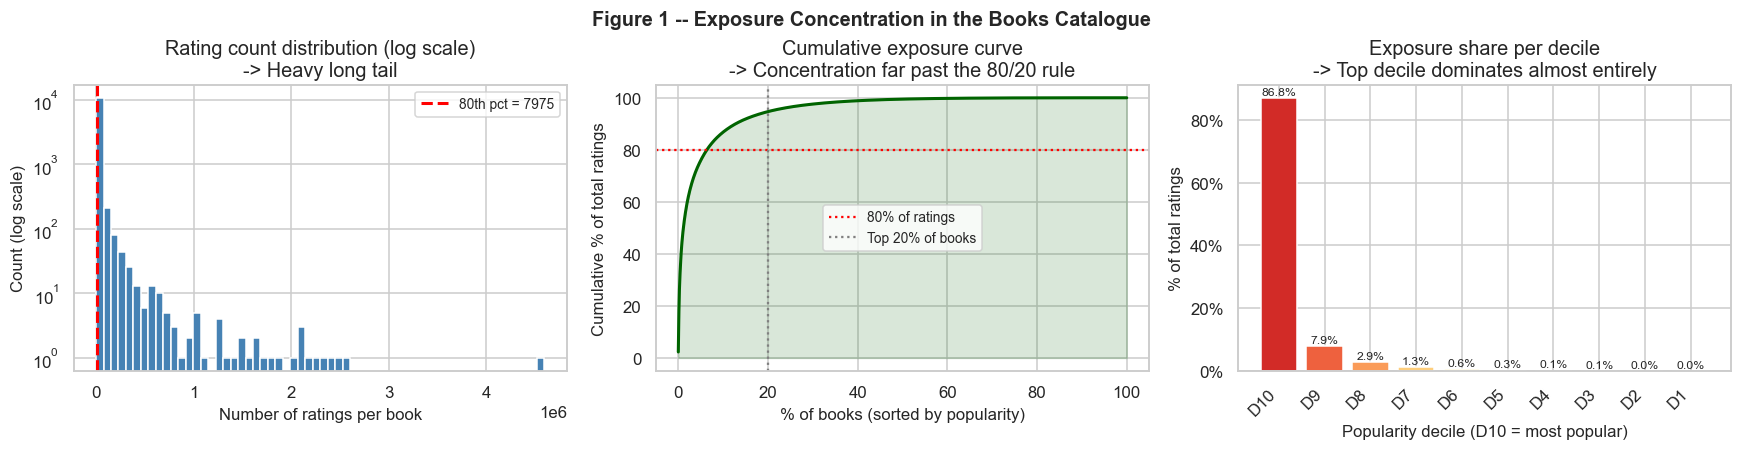

decile
D10    86.81
D9      7.88
D8      2.89
D7      1.29
D6      0.61
D5      0.29
D4      0.14
D3      0.06
D2      0.02
D1      0.00
Name: ratings_count, dtype: float64

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(item_stats['ratings_count'], bins=60, color='steelblue', edgecolor='white', log=True)
axes[0].axvline(pop_threshold, color='red', linestyle='--', lw=2,
                label=f'80th pct = {pop_threshold:.0f}')
axes[0].set_xlabel('Number of ratings per book')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Rating count distribution (log scale)\n-> Heavy long tail')
axes[0].legend(fontsize=9)

sorted_exp = item_stats['ratings_count'].sort_values(ascending=False)
cum_share  = sorted_exp.cumsum() / sorted_exp.sum() * 100
item_pct   = np.arange(1, len(sorted_exp) + 1) / len(sorted_exp) * 100

axes[1].plot(item_pct, cum_share, color='darkgreen', lw=2)
axes[1].axhline(80, color='red', linestyle=':', lw=1.5, label='80% of ratings')
axes[1].axvline(20, color='gray', linestyle=':', lw=1.5, label='Top 20% of books')
axes[1].fill_between(item_pct, cum_share, alpha=0.15, color='darkgreen')
axes[1].set_xlabel('% of books (sorted by popularity)')
axes[1].set_ylabel('Cumulative % of total ratings')
axes[1].set_title('Cumulative exposure curve\n-> Concentration far past the 80/20 rule')
axes[1].legend(fontsize=9)

item_stats['decile'] = pd.qcut(
    item_stats['ratings_count'].rank(method='first'), q=10,
    labels=[f'D{i}' for i in range(1, 11)]
)
decile_exp = (
    item_stats.groupby('decile', observed=True)['ratings_count'].sum()
    / item_stats['ratings_count'].sum() * 100
).sort_index(ascending=False)

colors = sns.color_palette('RdYlGn', 10)
axes[2].bar(range(10), decile_exp.values, color=colors, edgecolor='white')
axes[2].set_xticks(range(10))
axes[2].set_xticklabels(decile_exp.index, rotation=45, ha='right')
axes[2].set_xlabel('Popularity decile (D10 = most popular)')
axes[2].set_ylabel('% of total ratings')
axes[2].set_title('Exposure share per decile\n-> Top decile dominates almost entirely')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
for i, v in enumerate(decile_exp.values):
    axes[2].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.suptitle('Figure 1 -- Exposure Concentration in the Books Catalogue', y=1.02, fontsize=13, fontweight='bold')
plt.show()

display(decile_exp.round(2))

### Simple Explanation - Figure 1

This figure demonstrates exposure concentration in the books catalogue.

**What each graph shows:**
- **Left graph:** Shows how many ratings each book receives. It demonstrates that most books have low exposure, while a small number receive very high attention. The red dashed line marks the popularity threshold.
- **Middle graph:** Shows cumulative exposure. It demonstrates how quickly total ratings are captured by the most popular books.
- **Right graph:** Shows exposure share by popularity decile. It demonstrates that the top decile dominates total ratings.

**Simple takeaway:** Reader attention is extremely concentrated. A small group of books receives most ratings, while most books remain deep in the long tail.

---
## 3 -- Rating Quality Distribution

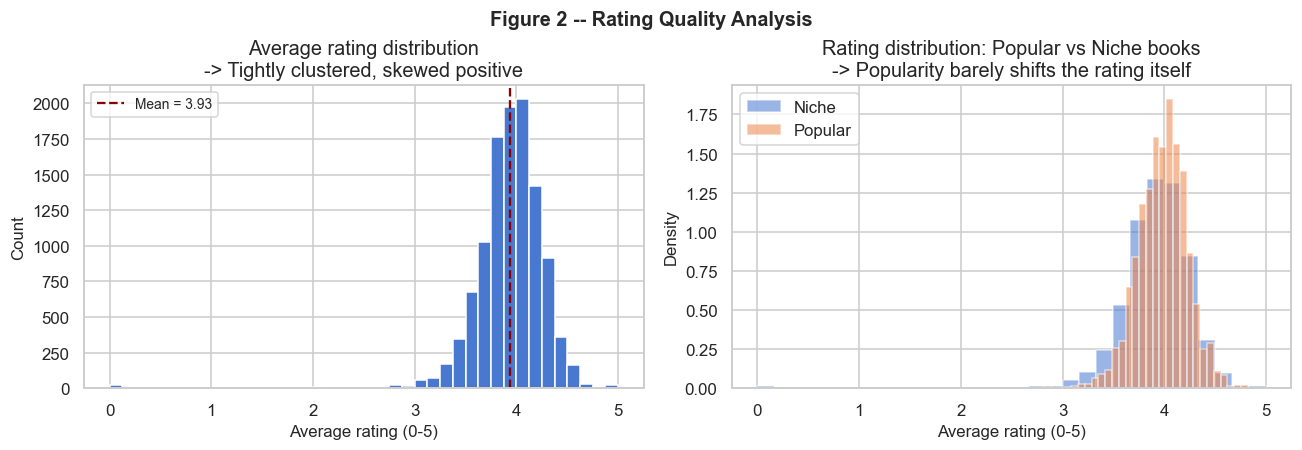

Mean average_rating -- Popular books: 3.984
Mean average_rating -- Niche books  : 3.922


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(item_stats['average_rating'], bins=40, color=sns.color_palette('muted')[0], edgecolor='white')
axes[0].set_xlabel('Average rating (0-5)')
axes[0].set_ylabel('Count')
axes[0].set_title('Average rating distribution\n-> Tightly clustered, skewed positive')
axes[0].axvline(item_stats['average_rating'].mean(), color='darkred', linestyle='--', lw=1.5,
                label=f'Mean = {item_stats["average_rating"].mean():.2f}')
axes[0].legend(fontsize=9)

item_stats['Popularity'] = item_stats['is_popular'].map({1: 'Popular', 0: 'Niche'})
for label, grp in item_stats.groupby('Popularity'):
    axes[1].hist(grp['average_rating'], bins=30, alpha=0.55, density=True, label=label)

axes[1].set_xlabel('Average rating (0-5)')
axes[1].set_ylabel('Density')
axes[1].set_title('Rating distribution: Popular vs Niche books\n-> Popularity barely shifts the rating itself')
axes[1].legend()

plt.tight_layout()
plt.suptitle('Figure 2 -- Rating Quality Analysis', y=1.02, fontsize=13, fontweight='bold')
plt.show()

print('Mean average_rating -- Popular books:', item_stats.loc[item_stats['is_popular']==1, 'average_rating'].mean().round(3))
print('Mean average_rating -- Niche books  :', item_stats.loc[item_stats['is_popular']==0, 'average_rating'].mean().round(3))

### Simple Explanation - Figure 2

This figure demonstrates book rating quality and how it relates to popularity.

**What each graph shows:**
- **Left graph:** Shows the distribution of average book ratings. It demonstrates that most books have fairly positive average ratings.
- **Right graph:** Compares average-rating distributions for popular and niche books. It demonstrates whether popular books are rated much better than niche books.

**Simple takeaway:** Popularity and quality are nearly separate here. Popular books are not necessarily much better rated than niche books; they are simply more visible.

Popularity and quality are nearly decoupled here: niche and popular books are rated
almost identically on average. Exposure, not quality, is what's scarce and unevenly
distributed in this catalogue -- a first hint that whatever drives a book's visibility
is largely separate from how good it actually is.

---
## 4 -- Author & Publisher Landscape

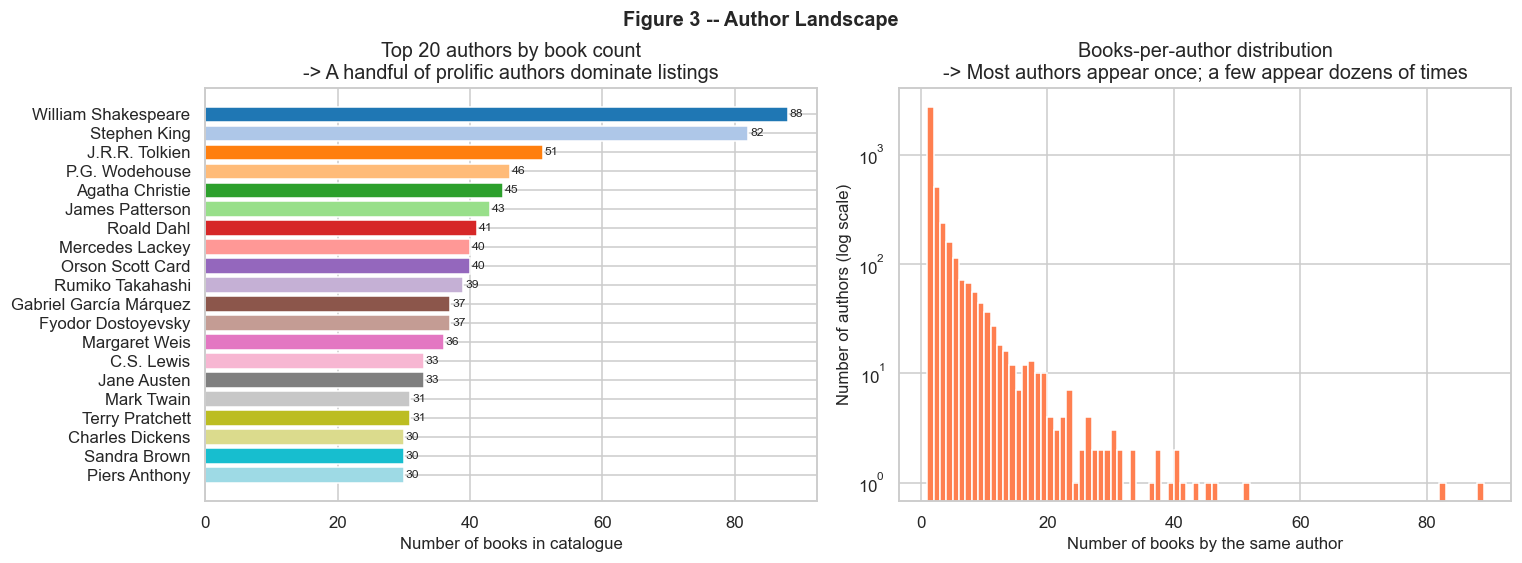

Unique primary authors : 4215
Authors with exactly 1 book: 2752 (65.3%)


In [19]:
books['primary_author'] = books['authors'].str.split('/').str[0]

author_counts = books['primary_author'].value_counts()
publisher_counts = books['publisher'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top20_authors = author_counts.head(20)
palette = sns.color_palette('tab20', len(top20_authors))
axes[0].barh(top20_authors.index[::-1], top20_authors.values[::-1], color=palette[::-1], edgecolor='white')
axes[0].set_xlabel('Number of books in catalogue')
axes[0].set_title('Top 20 authors by book count\n-> A handful of prolific authors dominate listings')
for i, v in enumerate(top20_authors.values[::-1]):
    axes[0].text(v + 0.3, i, str(v), va='center', fontsize=8)

axes[1].hist(author_counts.values, bins=range(1, author_counts.max()+2), color='coral', edgecolor='white', log=True)
axes[1].set_xlabel('Number of books by the same author')
axes[1].set_ylabel('Number of authors (log scale)')
axes[1].set_title('Books-per-author distribution\n-> Most authors appear once; a few appear dozens of times')

plt.tight_layout()
plt.suptitle('Figure 3 -- Author Landscape', y=1.02, fontsize=13, fontweight='bold')
plt.show()

print('Unique primary authors :', books['primary_author'].nunique())
print('Authors with exactly 1 book:', (author_counts == 1).sum(), f'({(author_counts==1).mean()*100:.1f}%)')

### Simple Explanation - Figure 3

This figure demonstrates the author structure of the books catalogue.

**What each graph shows:**
- **Left graph:** Shows the top 20 authors by number of books. It demonstrates that a few prolific authors contribute many titles.
- **Right graph:** Shows the books-per-author distribution. It demonstrates that most authors appear only once, while a few appear many times.

**Simple takeaway:** Book supply is uneven. The catalogue contains many one-book authors and a smaller set of highly represented authors.

---
## 5 -- Author-Level Exposure Inequality

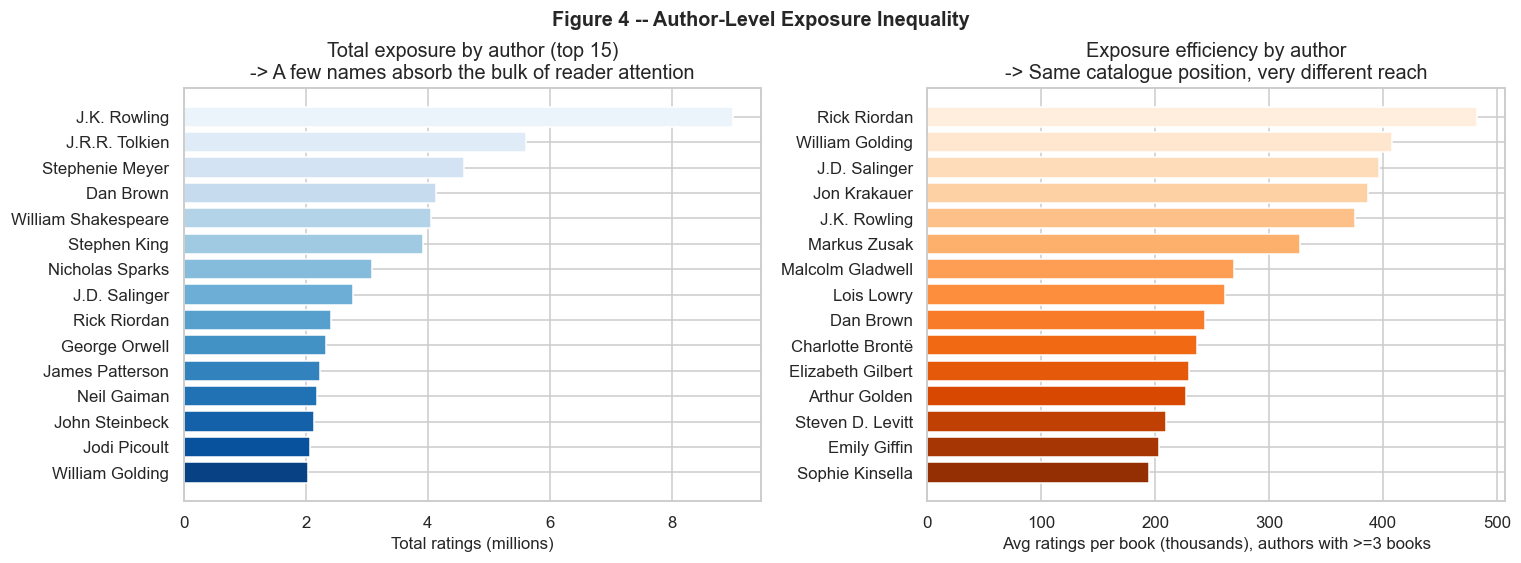

,primary_author,total_ratings,mean_rating,n_books,ratings_per_book
1598,J.K. Rowling,9005888,4.52,24,375245.33
1603,J.R.R. Tolkien,5601792,4.22,51,109839.06
3773,Stephenie Meyer,4597666,3.59,1,4597666.00
727,Dan Brown,4140267,3.82,17,243545.12
4161,William Shakespeare,4049289,3.93,88,46014.65
3753,Stephen King,3919914,4.00,82,47803.83
2940,Nicholas Sparks,3084994,4.00,18,171388.56
1592,J.D. Salinger,2778019,3.97,7,396859.86
3361,Rick Riordan,2413447,4.27,5,482689.40
1338,George Orwell,2327145,4.15,13,179011.15


In [20]:
author_exposure = (
    books.groupby('primary_author')
    .agg(
        total_ratings = ('ratings_count', 'sum'),
        mean_rating   = ('average_rating', 'mean'),
        n_books       = ('bookID', 'nunique'),
    )
    .reset_index()
)
author_exposure['ratings_per_book'] = author_exposure['total_ratings'] / author_exposure['n_books']
author_exposure = author_exposure.sort_values('total_ratings', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top15 = author_exposure.head(15)
palette = sns.color_palette('Blues_r', len(top15))
axes[0].barh(top15['primary_author'][::-1], top15['total_ratings'][::-1] / 1e6, color=palette, edgecolor='white')
axes[0].set_xlabel('Total ratings (millions)')
axes[0].set_title('Total exposure by author (top 15)\n-> A few names absorb the bulk of reader attention')

ae_sorted = author_exposure[author_exposure['n_books'] >= 3].sort_values('ratings_per_book', ascending=False).head(15)
axes[1].barh(ae_sorted['primary_author'][::-1], ae_sorted['ratings_per_book'][::-1] / 1e3,
             color=sns.color_palette('Oranges_r', len(ae_sorted)), edgecolor='white')
axes[1].set_xlabel('Avg ratings per book (thousands), authors with >=3 books')
axes[1].set_title('Exposure efficiency by author\n-> Same catalogue position, very different reach')

plt.tight_layout()
plt.suptitle('Figure 4 -- Author-Level Exposure Inequality', y=1.02, fontsize=13, fontweight='bold')
plt.show()

display(author_exposure.head(10).round(2))

### Simple Explanation - Figure 4

This figure demonstrates author-level exposure inequality.

**What each graph shows:**
- **Left graph:** Shows total ratings for the top authors. It demonstrates which authors receive the most reader attention overall.
- **Right graph:** Shows average ratings per book for authors with at least three books. It demonstrates which authors get high exposure per title, not only high exposure because they have many books.

**Simple takeaway:** Reader attention is concentrated around a few authors. Some authors dominate because they have many titles, while others have especially high reach per book.

---
## 6 -- Catalogue Concentration: Production vs Consumption

A ratings log lets us split "how many items exist" from "how much attention they
receive." Here we have no per-user log, but we can still ask the analogous question at
the author/publisher level: does the catalogue's production structure already look
unequal before any reader attention is added -- and if so, does attention make that
inequality worse?

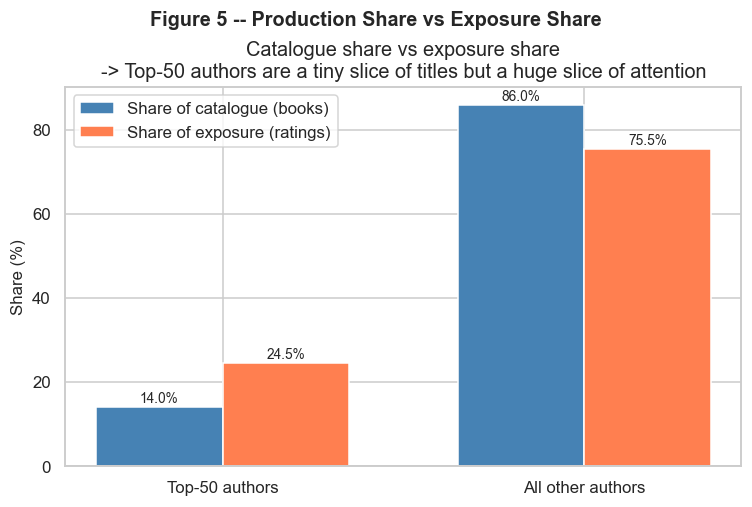

,n_books,total_ratings,catalogue_share_pct,exposure_share_pct
Top-50 authors,1561,48896369,14.03,24.5
All other authors,9562,150681930,85.97,75.5


In [21]:
top_authors = set(author_counts.head(50).index)
books['author_bucket'] = books['primary_author'].where(books['primary_author'].isin(top_authors), 'Other')

bucket_summary = (
    books.groupby(books['author_bucket'] == 'Other')
    .agg(n_books=('bookID', 'count'), total_ratings=('ratings_count', 'sum'))
)
bucket_summary.index = ['Top-50 authors', 'All other authors']
bucket_summary['catalogue_share_pct']  = bucket_summary['n_books'] / bucket_summary['n_books'].sum() * 100
bucket_summary['exposure_share_pct']   = bucket_summary['total_ratings'] / bucket_summary['total_ratings'].sum() * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, bucket_summary['catalogue_share_pct'], width, label='Share of catalogue (books)', color='steelblue', edgecolor='white')
ax.bar(x + width/2, bucket_summary['exposure_share_pct'], width, label='Share of exposure (ratings)', color='coral', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(bucket_summary.index)
ax.set_ylabel('Share (%)')
ax.set_title('Catalogue share vs exposure share\n-> Top-50 authors are a tiny slice of titles but a huge slice of attention')
ax.legend()
for i, (c, e) in enumerate(zip(bucket_summary['catalogue_share_pct'], bucket_summary['exposure_share_pct'])):
    ax.text(i - width/2, c + 1, f'{c:.1f}%', ha='center', fontsize=9)
    ax.text(i + width/2, e + 1, f'{e:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.suptitle('Figure 5 -- Production Share vs Exposure Share', y=1.02, fontsize=13, fontweight='bold')
plt.show()

display(bucket_summary.round(2))

### Simple Explanation - Figure 5

This figure demonstrates how production share differs from exposure share.

**What the graph shows:**
- **Grouped bar chart:** Compares the top 50 authors and all other authors by catalogue share and exposure share. It demonstrates whether a small author group receives more attention than its share of books.

**Simple takeaway:** The top authors are a small part of the catalogue but receive a much larger share of reader attention. Exposure amplifies existing author concentration.

The top 50 authors are a thin slice of the catalogue's titles, yet they absorb a
disproportionate slice of total exposure. Whatever mechanism allocates reader
attention amplifies an already-unequal production structure, rather than flattening
it.

---
## 7 -- Content-Profile Similarity: Popular vs Niche Books

This dataset has no genre tags, so we build a coarse content profile for each book --
primary author (bucketed to top-50 + "Other"), language, and publication decade -- and
one-hot encode it, the same way genres were one-hot encoded for movies. We then ask: do
popular books look more or less alike to each other than niche books do, in this
content space?

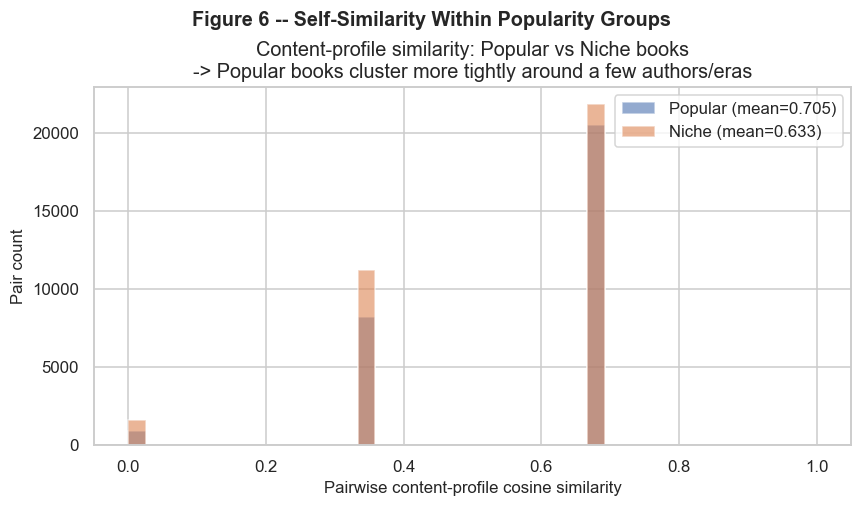

Mean pairwise similarity -- Popular books : 0.7054
Mean pairwise similarity -- Niche books   : 0.6331


In [22]:
books['pub_year'] = pd.to_datetime(books['publication_date'], errors='coerce').dt.year
books['decade'] = (books['pub_year'] // 10 * 10).astype('Int64')

profile_cols = pd.get_dummies(books[['author_bucket', 'language_code', 'decade']].astype(str))
norms = np.linalg.norm(profile_cols.values, axis=1, keepdims=True)
norms[norms == 0] = 1
profile_norm = profile_cols.values / norms

item_stats_idx = item_stats.reset_index(drop=True)
pop_flags = item_stats_idx['is_popular'].values
pop_idx   = np.where(pop_flags == 1)[0]
niche_idx = np.where(pop_flags == 0)[0]

rng = np.random.default_rng(42)
n_sample = 300
pop_sample   = profile_norm[rng.choice(pop_idx, n_sample, replace=False)]
niche_sample = profile_norm[rng.choice(niche_idx, min(n_sample, len(niche_idx)), replace=False)]

sim_popular = (pop_sample @ pop_sample.T)[np.triu_indices(n_sample, k=1)]
sim_niche   = (niche_sample @ niche_sample.T)[np.triu_indices(len(niche_sample), k=1)]

pop_mean, niche_mean = float(sim_popular.mean()), float(sim_niche.mean())

fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.linspace(0, 1, 40)
ax.hist(sim_popular, bins=bins, alpha=0.6, color='#4C72B0', label=f'Popular (mean={pop_mean:.3f})')
ax.hist(sim_niche,   bins=bins, alpha=0.6, color='#DD8452', label=f'Niche (mean={niche_mean:.3f})')
ax.set_xlabel('Pairwise content-profile cosine similarity')
ax.set_ylabel('Pair count')
ax.set_title('Content-profile similarity: Popular vs Niche books\n-> Popular books cluster more tightly around a few authors/eras')
ax.legend()

plt.tight_layout()
plt.suptitle('Figure 6 -- Self-Similarity Within Popularity Groups', y=1.02, fontsize=13, fontweight='bold')
plt.show()

print(f'Mean pairwise similarity -- Popular books : {pop_mean:.4f}')
print(f'Mean pairwise similarity -- Niche books   : {niche_mean:.4f}')

### Simple Explanation - Figure 6

This figure demonstrates content-profile similarity between popular and niche books.

**What the graph shows:**
- **Histogram:** Compares pairwise similarity for popular and niche books using author bucket, language, and publication decade. It demonstrates whether popular books are more alike than niche books.

**Simple takeaway:** Popular books cluster more tightly around similar authors, languages, or eras. Niche books are less visible but can be more varied as a group.

Popular books are more self-similar to each other than niche books are -- they
cluster around a smaller set of bestselling authors and eras. Niche books, despite being
less visible, are actually more varied in their content profile as a group. That's a
useful but slightly counter-intuitive structural fact: pulling more niche books into view
doesn't automatically risk making a set of recommendations repetitive -- niche books
already look less alike than popular ones do.

---
## 8 -- Exposure Choices Reshape the Effective Catalogue

If a reading list (or storefront shelf, or "for you" rail) is built mostly from popular
books, how much of the underlying catalogue actually gets surfaced across many such
lists? We simulate lists of varying niche-book fraction and track how much of the full
catalogue gets touched as that fraction increases.

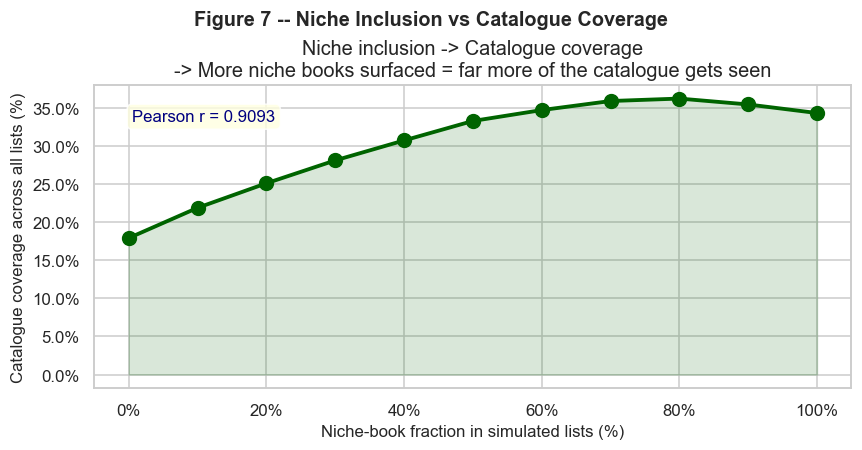

,niche_frac,Coverage
0,0.0,0.1790
1,0.1,0.2186
2,0.2,0.2508
3,0.3,0.2809
4,0.4,0.3070
5,0.5,0.3326
6,0.6,0.3468
7,0.7,0.3587
8,0.8,0.3620
9,0.9,0.3542


In [23]:
popular_ids = item_stats_idx.loc[pop_flags == 1, 'bookID'].values
niche_ids   = item_stats_idx.loc[pop_flags == 0, 'bookID'].values

n_sim_lists = 500
K           = 10
niche_fracs = np.arange(0.0, 1.05, 0.1)

rows_sim = []
rng = np.random.default_rng(42)

for nf in niche_fracs:
    n_niche = int(round(K * nf))
    n_pop   = K - n_niche
    all_picks = set()

    for _ in range(n_sim_lists):
        picks = []
        if n_pop > 0:
            picks += rng.choice(popular_ids, n_pop, replace=False).tolist()
        if n_niche > 0:
            picks += rng.choice(niche_ids, n_niche, replace=False).tolist()
        all_picks.update(picks)

    coverage = len(all_picks) / n_books
    rows_sim.append({'niche_frac': nf, 'Coverage': coverage})

sim_df = pd.DataFrame(rows_sim)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sim_df['niche_frac'] * 100, sim_df['Coverage'] * 100, 'o-', color='darkgreen', lw=2.5, ms=9, zorder=3)
ax.fill_between(sim_df['niche_frac'] * 100, sim_df['Coverage'] * 100, alpha=0.15, color='darkgreen')
ax.set_xlabel('Niche-book fraction in simulated lists (%)')
ax.set_ylabel('Catalogue coverage across all lists (%)')
ax.set_title('Niche inclusion -> Catalogue coverage\n-> More niche books surfaced = far more of the catalogue gets seen')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

r, _ = pearsonr(sim_df['niche_frac'], sim_df['Coverage'])
ax.text(0.05, 0.88, f'Pearson r = {r:.4f}', transform=ax.transAxes, fontsize=11, color='navy',
        bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.8))

plt.tight_layout()
plt.suptitle('Figure 7 -- Niche Inclusion vs Catalogue Coverage', y=1.02, fontsize=13, fontweight='bold')
plt.show()

display(sim_df.round(4))

### Simple Explanation - Figure 7

This figure demonstrates how niche inclusion affects catalogue coverage.

**What the graph shows:**
- **Line graph:** Shows catalogue coverage as the niche-book fraction in simulated lists increases. It demonstrates whether adding niche books helps expose more of the full catalogue.

**Simple takeaway:** More niche books in lists greatly improves catalogue coverage. This supports using niche inclusion as a way to reduce exposure concentration.

Coverage rises steeply and almost linearly as the niche fraction increases, before
flattening out near the top -- there's a point past which adding still more niche books
stops buying much extra coverage, because the lists start exhausting the small niche pool
itself relative to how many lists are being built.

---
## 9 -- Popularity's Footprint on the Observed Author/Language Mix

Finally: does restricting attention to popular books distort the apparent shape of the
catalogue -- its mix of authors, languages, and eras -- relative to the catalogue as it
actually exists?

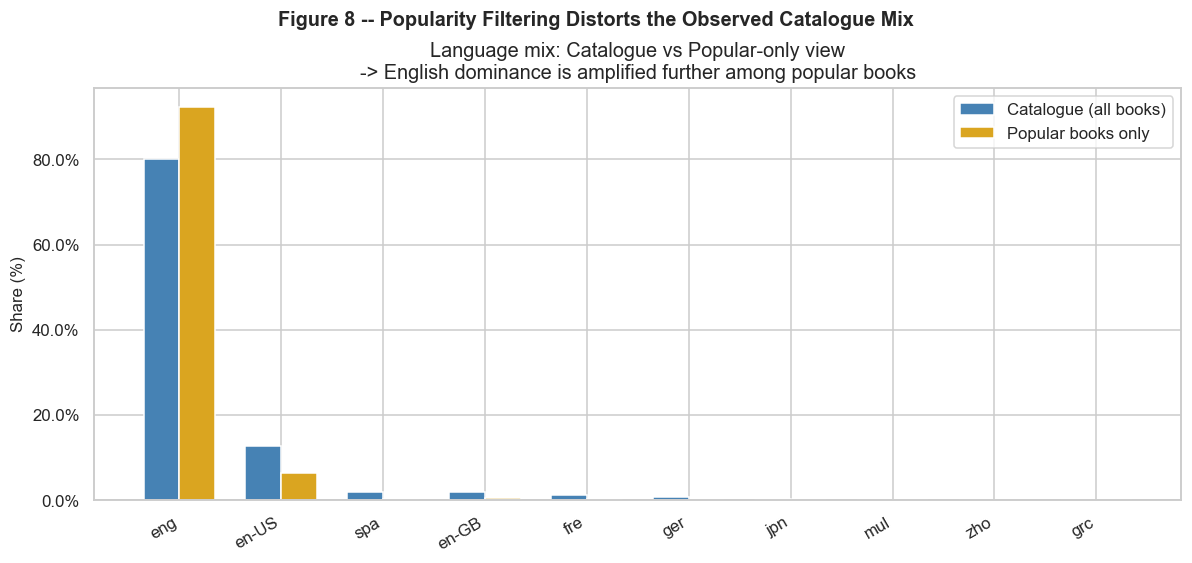

,Catalogue,Popular books
language_code,,
eng,0.8009,0.9218
en-US,0.1266,0.0652
spa,0.0196,0.0027
en-GB,0.0192,0.0063
fre,0.0129,0.0027
ger,0.0089,0.0004
jpn,0.0041,0.0000
mul,0.0017,0.0000
zho,0.0013,0.0000


In [24]:
catalogue_lang_dist = books['language_code'].value_counts(normalize=True).rename('Catalogue')

popular_book_ids = item_stats_idx.loc[pop_flags == 1, 'bookID']
popular_lang_dist = (
    books[books['bookID'].isin(popular_book_ids)]['language_code']
    .value_counts(normalize=True)
).rename('Popular books')

lang_dist_df = pd.DataFrame([catalogue_lang_dist, popular_lang_dist]).T.fillna(0)
lang_dist_df = lang_dist_df.sort_values('Catalogue', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(lang_dist_df))
width = 0.35
ax.bar(x - width/2, lang_dist_df['Catalogue'] * 100, width, label='Catalogue (all books)', color='steelblue', edgecolor='white')
ax.bar(x + width/2, lang_dist_df['Popular books'] * 100, width, label='Popular books only', color='goldenrod', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(lang_dist_df.index, rotation=30, ha='right')
ax.set_ylabel('Share (%)')
ax.set_title('Language mix: Catalogue vs Popular-only view\n-> English dominance is amplified further among popular books')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.tight_layout()
plt.suptitle('Figure 8 -- Popularity Filtering Distorts the Observed Catalogue Mix', y=1.02, fontsize=13, fontweight='bold')
plt.show()

display(lang_dist_df.round(4))

### Simple Explanation - Figure 8

This figure demonstrates how popularity filtering changes the visible language mix.

**What the graph shows:**
- **Grouped bar chart:** Compares language shares in the full catalogue and in popular books only. It demonstrates whether popularity makes dominant languages even more dominant.

**Simple takeaway:** Popularity filtering distorts the visible catalogue. English and other dominant language groups can become even more prominent among popular books than in the full catalogue.

---
## 10 - Overall EDA Insights

### Main Findings

1. **Exposure concentration is extreme.** A small fraction of books receives almost all logged ratings, while most books receive far less attention.

2. **Popularity and rating quality are nearly decoupled.** Popular books and niche books have similar average-rating distributions, meaning visibility is not simply the same as quality.

3. **The author landscape is uneven.** A few prolific authors contribute many books, while most authors appear only once.

4. **Reader attention amplifies author concentration.** Top authors represent a small share of the catalogue but receive a much larger share of total exposure.

5. **Exposure efficiency varies by author.** Some authors receive many ratings per book, while others need more catalogue volume to gain similar attention.

6. **Popular books are more self-similar.** Popular books cluster more tightly around certain authors, languages, and publication periods, while niche books are more varied as a group.

7. **Niche inclusion improves catalogue coverage.** Adding more niche books to simulated lists exposes much more of the catalogue, especially before coverage starts to flatten.

8. **Popularity filtering distorts the visible catalogue.** The popular-only view changes the apparent language mix and makes dominant groups even more visible.

### Final Conclusion

The Books EDA shows that reader attention is much more concentrated than book quality. Popular books dominate exposure, but niche books can be equally well rated and more varied. A better recommender should balance relevance with catalogue coverage, author diversity, and reduced popularity bias.